In [1]:
# Load packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.metrics.pairwise import euclidean_distances

from FDApy import DenseFunctionalData, MultivariateFunctionalData
from FDApy.representation import DenseArgvals, DenseValues
from FDApy.preprocessing import MFPCA
from FDApy.visualization import plot, plot_multivariate

from nba import NbaScraper, ShotCharts

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r'\usepackage{amsfonts}'
})

In [2]:
# Load data
with open('./data/players_shots_density_attempted.pickle', 'rb') as f:
    players_shots_density = pickle.load(f)
with open('./data/players_shots_density_made.pickle', 'rb') as f:
    players_shots_density_made = pickle.load(f)
with open('./data/player_position.pickle', 'rb') as f:
    players_position = pickle.load(f)

# Load MFPCA results
with open('./data/MFPCA.pickle', 'rb') as f:
    mfpca = pickle.load(f)
with open('./data/scores.pickle', 'rb') as f:
    scores = pickle.load(f)
with open('./data/MFPCA_reconstruction.pickle', 'rb') as f:
    fdata_reconstruction = pickle.load(f)

In [3]:
# Reshape scores
scores = pd.DataFrame(scores)
scores.insert(loc=0, column='PLAYER_ID', value=players_shots_density.PLAYER_ID.values)
scores.insert(loc=0, column='PLAYER_NAME', value=players_shots_density.PLAYER_NAME.values)
scores = scores.join(players_position.set_index('PLAYER_ID'), how='left', on='PLAYER_ID', rsuffix='_')

In [4]:
scores_mat = scores[[0, 1, 2, 3]].values

In [5]:
scaler = StandardScaler()
scaler.fit(scores_mat)
new_scores = scaler.transform(scores_mat)

In [6]:
# Compute distances betwween scores
distance_scores = euclidean_distances(new_scores)

In [7]:
# K-means
kmeans = KMeans(n_clusters=5).fit(new_scores)

In [8]:
results = {
    'centers': kmeans.cluster_centers_,
    'pred': kmeans.predict(new_scores)
}

In [9]:
with open('./data/distance_scores.pickle', 'wb') as f:
    pickle.dump(distance_scores, f, protocol=pickle.HIGHEST_PROTOCOL)

In [10]:
with open('./data/clustering.pickle', 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

In [11]:
# Weighted K-means
pct = mfpca.eigenvalues / np.sum(mfpca.eigenvalues)
weighted_scores = np.multiply(new_scores, pct[:4])

In [12]:
# Compute distances betwween weighted scores
distance_weighted_scores = euclidean_distances(weighted_scores)

In [13]:
kmeans = KMeans(n_clusters=5).fit(weighted_scores)

In [14]:
results = {
    'centers': kmeans.cluster_centers_,
    'pred': kmeans.predict(weighted_scores)
}

In [15]:
with open('./data/distance_weighted_scores.pickle', 'wb') as f:
    pickle.dump(distance_weighted_scores, f, protocol=pickle.HIGHEST_PROTOCOL)

In [16]:
with open('./data/clustering_weighted.pickle', 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

In [17]:
# K-medoids
kmedoids = KMedoids(n_clusters=5).fit(new_scores)

In [18]:
results = {
    'centers': kmedoids.cluster_centers_,
    'idx_centers': [np.argmax(np.isclose(new_scores[:, 0], kmedoids.cluster_centers_[idx, 0])) for idx in range(5)],
    'pred': kmedoids.predict(new_scores)
}

In [19]:
with open('./data/clustering_kmedoids.pickle', 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

In [20]:
# Weighted K-medoids
kmedoids = KMedoids(n_clusters=5).fit(weighted_scores)

In [21]:
results = {
    'centers': kmedoids.cluster_centers_,
    'idx_centers': [np.argmax(np.isclose(weighted_scores[:, 0], kmedoids.cluster_centers_[idx, 0])) for idx in range(5)],
    'pred': kmedoids.predict(weighted_scores)
}

In [22]:
with open('./data/clustering_kmedoids_weighted.pickle', 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

In [36]:
# Silhouette plot of KMedoids with unweighted scores
from sklearn.metrics import silhouette_score

k_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
silhouette_scores = np.zeros(len(k_list))
for idx, k in enumerate(k_list):
    kmedoids = KMedoids(n_clusters=k).fit(new_scores)
    prediction = kmedoids.predict(new_scores)
    silhouette_scores[idx] = silhouette_score(distance_scores, prediction, metric='precomputed')


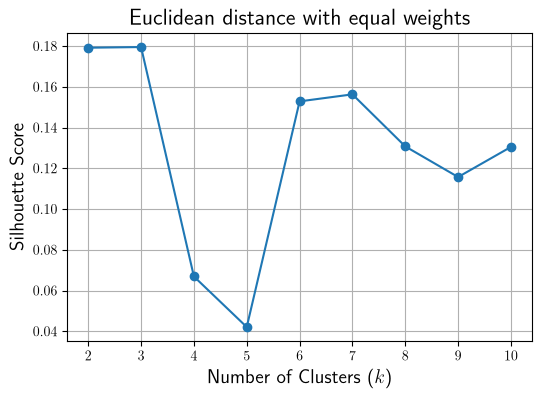

In [37]:
# Plot the silhouette scores
plt.figure(figsize=(6, 4))
plt.plot(k_list, silhouette_scores, marker='o')
plt.title('Euclidean distance with equal weights', fontsize=16)
plt.xlabel('Number of Clusters ($k$)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.xticks(k_list)
plt.grid()
plt.savefig(f'./figures/silhouette_kmedoids_no_weights.eps', transparent=True, format='eps')
plt.show()

In [39]:
# Silhouette plot of KMedoids with weighted scores
from sklearn.metrics import silhouette_score

k_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
silhouette_scores = np.zeros(len(k_list))
for idx, k in enumerate(k_list):
    kmedoids = KMedoids(n_clusters=k).fit(weighted_scores)
    prediction = kmedoids.predict(weighted_scores)
    silhouette_scores[idx] = silhouette_score(distance_scores, prediction, metric='precomputed')

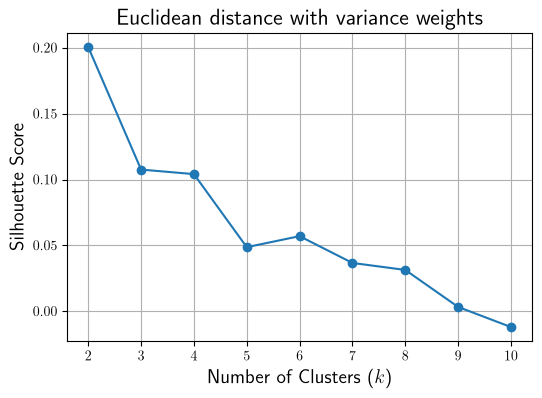

In [40]:
# Plot the silhouette scores
plt.figure(figsize=(6, 4))
plt.plot(k_list, silhouette_scores, marker='o')
plt.title('Euclidean distance with variance weights', fontsize=16)
plt.xlabel('Number of Clusters ($k$)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.xticks(k_list)
plt.grid()
plt.savefig(f'./figures/silhouette_kmedoids_variance_weights.eps', transparent=True, format='eps')
plt.show()